In [16]:
import xarray as xr
import matplotlib as plt
from dask_jobqueue import PBSCluster
from dask.distributed import Client

In [17]:
cluster = PBSCluster(
    cores=1,
    memory='32GB',
    processes=1,
    queue='casper',
    local_directory='$TMPDIR',
    account='P93300313',
    walltime='4:00:00'
)
cluster.scale(jobs=10)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.178:35003,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/acruz/Analysis/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [18]:
def calc_RH(T, Td):
    # Using August-Roche-Magnus approximation for vapor pressure
    # calculate RH, keeping as fraction
    a = 17.625
    b = 243.04
    vp_a = xr.ufuncs.exp(((a * Td) / (b + Td)))
    vp_s = xr.ufuncs.exp(((a * T)/(b + T)))
    return (vp_a / vp_s)


def calc_HI(T, RH):
    # Rothfusz equation
    HI = ( -42.379 + 2.04901523 * T + 10.14333127 * RH -0.22475541 * T * RH 
          - 0.00683783 * T * T - 0.05481717 * RH * RH + 0.00122874 * T * T * RH
          + 0.00085282 * T * RH * RH - 0.00000199 * T * T * RH * RH
         )
    return HI

In [8]:
tds = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/sfc_hourly_temp')
tds

<xarray.Dataset> Size: 19GB
Dimensions:    (time: 755304, latitude: 61, longitude: 101)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 488B 10.0 10.25 10.5 10.75 ... 24.5 24.75 25.0
  * longitude  (longitude) float64 808B -85.0 -84.75 -84.5 ... -60.25 -60.0
Data variables:
    VAR_2T     (time, latitude, longitude) float32 19GB dask.array<chunksize=(22888, 61, 101), meta=np.ndarray>

In [19]:
dds = xr.open_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/sfc_hourly_dew')
dds

<xarray.Dataset> Size: 19GB
Dimensions:    (time: 755304, latitude: 61, longitude: 101)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 488B 10.0 10.25 10.5 10.75 ... 24.5 24.75 25.0
  * longitude  (longitude) float64 808B -85.0 -84.75 -84.5 ... -60.25 -60.0
Data variables:
    VAR_2D     (time, latitude, longitude) float32 19GB dask.array<chunksize=(22888, 61, 101), meta=np.ndarray>

## data check

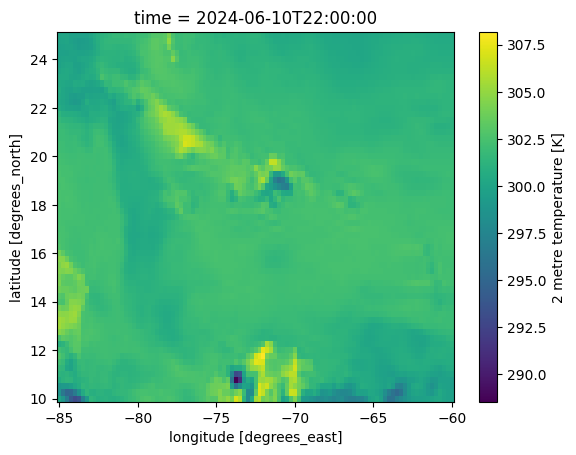

In [12]:
tds['VAR_2T'].isel(time=740230).plot()

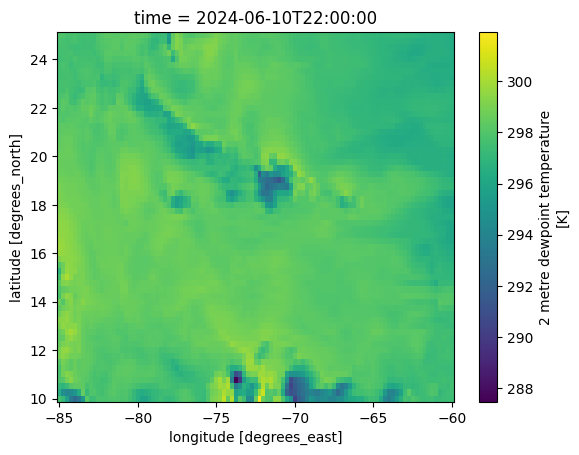

In [13]:
dds['VAR_2D'].isel(time=740230).plot()

## Calc HI

In [20]:
RH_da = calc_RH(tds['VAR_2T'], dds['VAR_2D'])
RH_da

<xarray.DataArray (time: 755304, latitude: 61, longitude: 101)> Size: 19GB
dask.array<truediv, shape=(755304, 61, 101), dtype=float32, chunksize=(22888, 61, 101), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 488B 10.0 10.25 10.5 10.75 ... 24.5 24.75 25.0
  * longitude  (longitude) float64 808B -85.0 -84.75 -84.5 ... -60.25 -60.0
Attributes:
    units:                                              K
    original_format:                                    WMO GRIB 1 with ECMWF...
    ecmwf_local_table:                                  128
    grid_specification:                                 0.25 degree x 0.25 de...
    rda_dataset:                                        ds633.0
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7

In [22]:
HI_da = calc_HI(tds['VAR_2T'], RH_da).drop_attrs()
HI_da

<xarray.DataArray (time: 755304, latitude: 61, longitude: 101)> Size: 19GB
dask.array<sub, shape=(755304, 61, 101), dtype=float32, chunksize=(22888, 61, 101), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-02-28T23:00:00
  * latitude   (latitude) float64 488B 10.0 10.25 10.5 10.75 ... 24.5 24.75 25.0
  * longitude  (longitude) float64 808B -85.0 -84.75 -84.5 ... -60.25 -60.0

In [23]:
HI_da.to_zarr('/glade/work/acruz/Caribbean_Heat_data/ERA5/hourly_HI', mode='w')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [24]:
client.shutdown()